# Online Retail Revenue and Customer Trend Analysis

This project analyzes 12 months of real transaction data from a UK-based online retailer. 
The goal is to uncover patterns in revenue, customer behavior, and geographic performance 
that could help inform business decisions.

**Dataset:** UCI Machine Learning Repository — Online Retail Dataset  

**Tools:** Python, pandas, matplotlib, seaborn, prophet

**Author:** Joseph Viscione

In [1]:
import warnings
warnings.filterwarnings("ignore")

# standard imports for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

# makes our charts look cleaner throughout the notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# just so we can see all columns when we inspect the dataframe
pd.set_option("display.max_columns", None)

Importing plotly failed. Interactive plots will not work.


## 2. Loading the Data

Let's load the dataset and take a first look at what we're working with — 
the shape, the columns, and whether anything looks off right away.

In [2]:
# load the dataset from our data folder
df = pd.read_excel("../data/Online Retail.xlsx")

# first look — how big is this thing?
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [3]:
# look at the first few rows to get a feel for the data
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# check data types and see if anything looks wrong
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
# check exactly how many values are missing in each column
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 3. Data Cleaning

From the initial inspection we know a few things need to be addressed before we can trust the numbers:

- **135,080 rows are missing a CustomerID** — these are likely guest transactions with no customer tracking
- **1,454 rows are missing a Description** — small enough to drop without losing much
- **Some invoices start with 'C'** — these are cancellations and will skew revenue if left in
- **Some Quantity values are negative** — another sign of returns or cancellations

We'll handle all of these before moving to analysis.

In [6]:
# remove rows with missing descriptions - there are only ~1,400 so no big loss
df.dropna(subset=["Description"], inplace=True)

# remove cancellations - invoices starting with 'C' are returns/cancellations
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# remove rows with negative or zero quantity - these are returns or data errors
df = df[df["Quantity"] > 0]

# remove rows with negative or zero unit price - not real transactions
df = df[df["UnitPrice"] > 0]

# create a Revenue column - this is the core metric we'll use throughout
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# check what we're left with
print("Cleaned shape:", df.shape)
print("Missing values remaining:")
print(df.isnull().sum())

Cleaned shape: (530104, 9)
Missing values remaining:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132220
Country             0
Revenue             0
dtype: int64


## 4. Revenue Trend Analysis

With clean data in hand, the first question is simple — when was this business making money? 

Let's break revenue down by month and see what the pattern looks like over the year.

In [7]:
# group revenue by month
df["Month"] = df["InvoiceDate"].dt.to_period("M")
monthly_revenue = df.groupby("Month")["Revenue"].sum().reset_index()
monthly_revenue["Month"] = monthly_revenue["Month"].astype(str)

print(monthly_revenue)

      Month      Revenue
0   2010-12   823746.140
1   2011-01   691364.560
2   2011-02   523631.890
3   2011-03   717639.360
4   2011-04   537808.621
5   2011-05   770536.020
6   2011-06   761739.900
7   2011-07   719221.191
8   2011-08   759138.380
9   2011-09  1058590.172
10  2011-10  1154979.300
11  2011-11  1509496.330
12  2011-12   638792.680


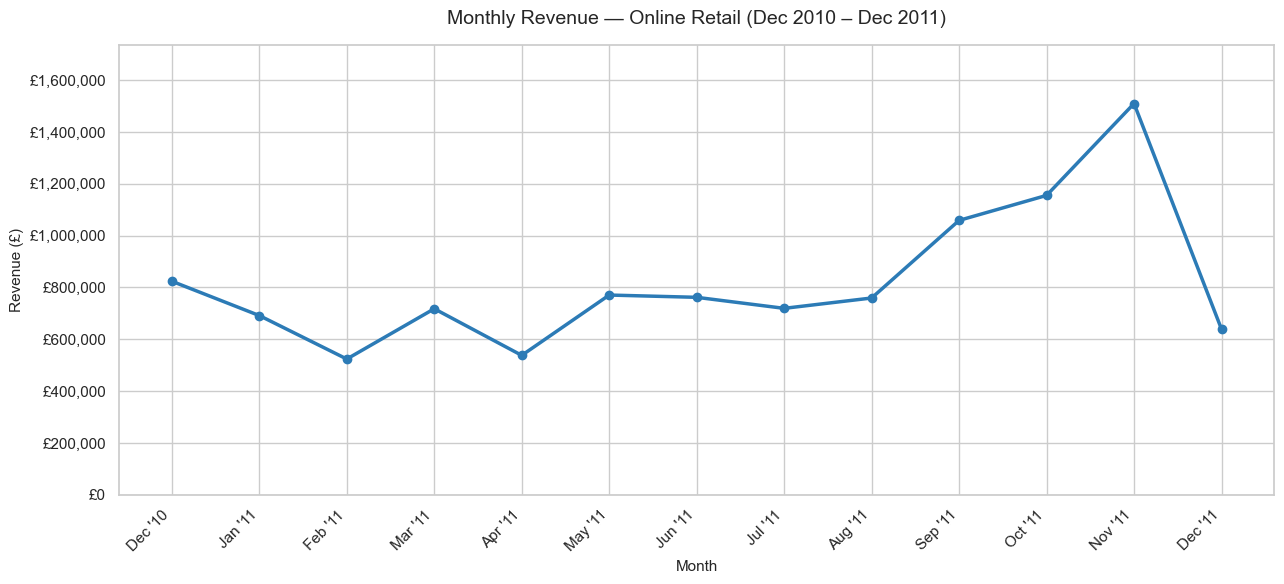

In [8]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(monthly_revenue["Month"], monthly_revenue["Revenue"], 
        marker="o", color="#2c7bb6", linewidth=2.5, markersize=6)

# format y-axis to show readable pound amounts instead of scientific notation
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"£{x:,.0f}"))

# use readable month name labels instead of numeric
month_labels = ["Dec '10", "Jan '11", "Feb '11", "Mar '11", "Apr '11", "May '11",
                "Jun '11", "Jul '11", "Aug '11", "Sep '11", "Oct '11", "Nov '11", "Dec '11"]

ax.set_xticks(range(len(monthly_revenue)))
ax.set_xticklabels(month_labels, rotation=45, ha="right")

ax.set_title("Monthly Revenue — Online Retail (Dec 2010 – Dec 2011)", fontsize=14, pad=15)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Revenue (£)", fontsize=11)
plt.ylim(0, monthly_revenue["Revenue"].max() * 1.15)
plt.tight_layout()

plt.savefig("../outputs/figures/monthly_revenue.png", dpi=150)
plt.show()

Revenue stayed relatively flat through the first half of the year before climbing sharply 
starting in September. November was the clear peak at roughly £1.5 million — likely driven 
by holiday wholesale ordering. Additionally, December appears to drop off, but the dataset only runs 
through December 9th, making it an incomplete month rather than a true decline.

The bigger takeaway: This is a highly seasonal business. Q4 generates nearly twice the revenue 
of Q1 and Q2 combined, which has real implications for inventory planning, staffing, and cash flow management.

## 5. Customer Analysis

Revenue trends tell us when the business performs well — but who is actually driving that revenue? 
Here we look at the top customers by total spend to understand how concentrated the business really is.

In [9]:
# filter out rows with no customer ID — these are guest transactions
df_customers = df.dropna(subset=["CustomerID"])

# total revenue per customer
customer_revenue = df_customers.groupby("CustomerID")["Revenue"].sum().reset_index()
customer_revenue.columns = ["CustomerID", "TotalRevenue"]
customer_revenue = customer_revenue.sort_values("TotalRevenue", ascending=False)

# look at the top 10
print(customer_revenue.head(10))

      CustomerID  TotalRevenue
1689     14646.0     280206.02
4201     18102.0     259657.30
3728     17450.0     194550.79
3008     16446.0     168472.50
1879     14911.0     143825.06
55       12415.0     124914.53
1333     14156.0     117379.63
3771     17511.0      91062.38
2702     16029.0      81024.84
0        12346.0      77183.60


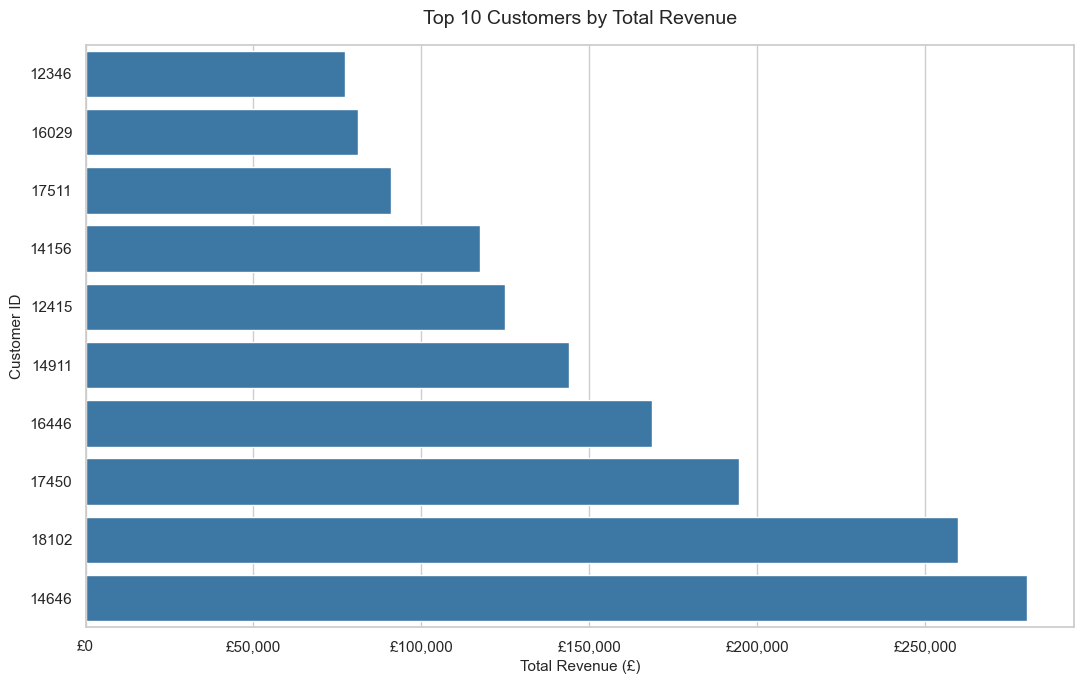

In [10]:
top_customers = customer_revenue.head(10).copy()
top_customers["CustomerID"] = top_customers["CustomerID"].astype(int).astype(str)
top_customers = top_customers.sort_values("TotalRevenue", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(data=top_customers, y="CustomerID", x="TotalRevenue", 
            color="#2c7bb6", ax=ax)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.set_title("Top 10 Customers by Total Revenue", fontsize=14, pad=15)
ax.set_xlabel("Total Revenue (£)", fontsize=11)
ax.set_ylabel("Customer ID", fontsize=11)
plt.tight_layout()

plt.savefig("../outputs/figures/top_customers.png", dpi=150)
plt.show()

The revenue concentration here is striking. Customer 14646 alone generated over £280,000, which is nearly £20,000 more than the second-highest customer. The top 10 customers collectively represent a significant portion of total revenue, which is a real business risk. This means that if even two or three of these accounts churned, the impact on the bottom line would be substantial.

For a wholesale-oriented retailer like this one, identifying and retaining high-value customers isn't just good practice — it's a core business priority.

## 6. Country Analysis

The dataset covers customers from multiple countries, but how evenly distributed is that revenue? 
Here we look at which markets are actually driving the business and how dependent the retailer 
is on any single country.

In [11]:
# total revenue by country
country_revenue = df.groupby("Country")["Revenue"].sum().reset_index()
country_revenue.columns = ["Country", "TotalRevenue"]
country_revenue = country_revenue.sort_values("TotalRevenue", ascending=False)

print(country_revenue.head(10))

           Country  TotalRevenue
36  United Kingdom   9025222.084
24     Netherlands    285446.340
10            EIRE    283453.960
14         Germany    228867.140
13          France    209715.110
0        Australia    138521.310
31           Spain     61577.110
33     Switzerland     57089.900
3          Belgium     41196.340
32          Sweden     38378.330


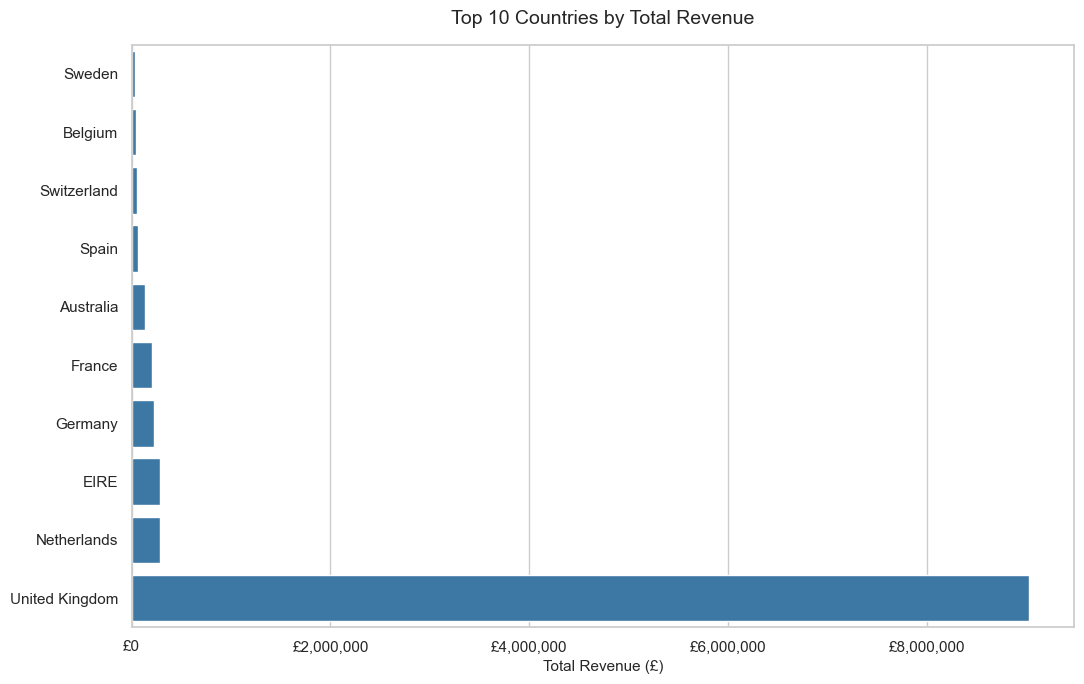

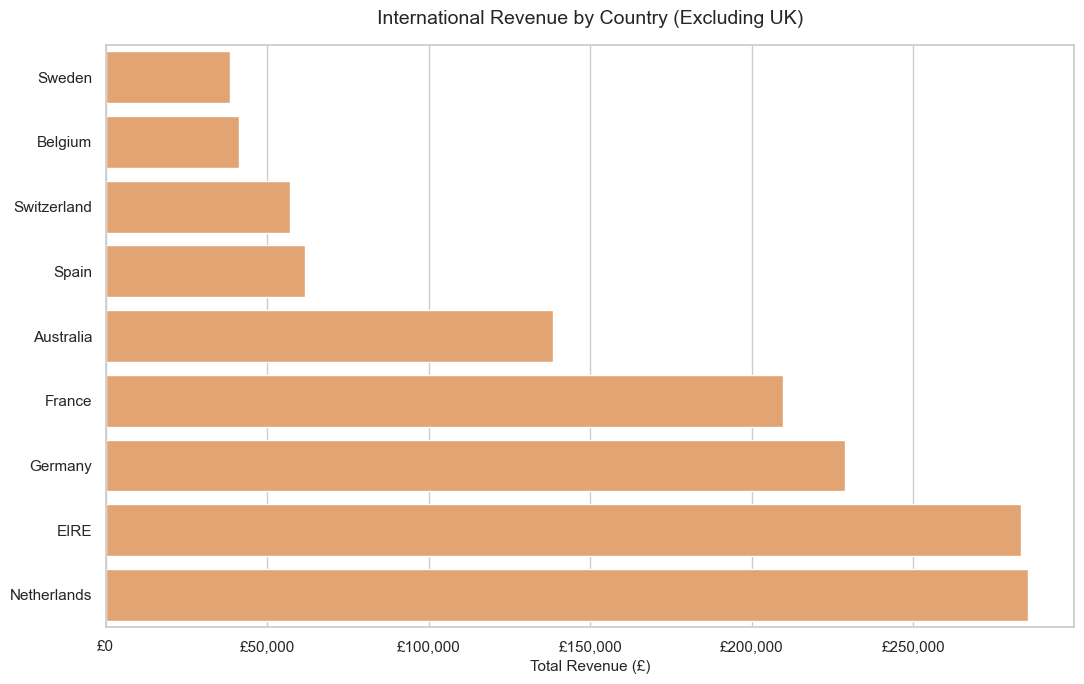

In [12]:
# chart 1 — all countries including UK to show the full picture
top_countries = country_revenue.head(10).copy()
top_countries = top_countries.sort_values("TotalRevenue", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=top_countries, y="Country", x="TotalRevenue", color="#2c7bb6", ax=ax)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.set_title("Top 10 Countries by Total Revenue", fontsize=14, pad=15)
ax.set_xlabel("Total Revenue (£)", fontsize=11)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../outputs/figures/top_countries.png", dpi=150)
plt.show()

# chart 2 — international only (ex-UK) to see the breakdown more clearly
top_international = country_revenue[country_revenue["Country"] != "United Kingdom"].head(9).copy()
top_international = top_international.sort_values("TotalRevenue", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=top_international, y="Country", x="TotalRevenue", color="#f4a261", ax=ax)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.set_title("International Revenue by Country (Excluding UK)", fontsize=14, pad=15)
ax.set_xlabel("Total Revenue (£)", fontsize=11)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../outputs/figures/international_revenue.png", dpi=150)
plt.show()

Based on the graphs above, he geographic concentration here is hard to ignore. The UK accounts for the overwhelming  majority of revenue — dwarfing every other market combined. Among international markets, the Netherlands and EIRE (Ireland) lead the pack, followed by Germany and France.

This level of home-market dependence is a meaningful business risk. If UK demand softened for any reason, there's no international market large enough to compensate. On the flip side, the presence of customers across Europe and as far as Australia suggests there's real international demand worth developing.

## 7. Product Analysis

With revenue and customer trends covered, it's worth taking a quick look at the products themselves. Which items are generating the most revenue, and is there anything notable about what's driving the top of the list?

In [13]:
# total revenue by product description
product_revenue = df.groupby("Description")["Revenue"].sum().reset_index()
product_revenue.columns = ["Product", "TotalRevenue"]
product_revenue = product_revenue.sort_values("TotalRevenue", ascending=False)

print(product_revenue.head(10))

                                 Product  TotalRevenue
1067                      DOTCOM POSTAGE     206248.77
2853            REGENCY CAKESTAND 3 TIER     174484.74
2387         PAPER CRAFT , LITTLE BIRDIE     168469.60
3844  WHITE HANGING HEART T-LIGHT HOLDER     106292.77
2413                       PARTY BUNTING      99504.33
1816             JUMBO BAG RED RETROSPOT      94340.05
2052      MEDIUM CERAMIC TOP STORAGE JAR      81700.92
2192                              Manual      78112.82
2692                             POSTAGE      78101.88
2741                  RABBIT NIGHT LIGHT      66964.99


In [14]:
# filter out non-product entries like postage and manual charges
non_products = ["DOTCOM POSTAGE", "POSTAGE", "Manual", "AMAZONFEE", "Bank Charges"]
product_revenue = product_revenue[~product_revenue["Product"].isin(non_products)]

# now look at the actual top 10 products
print(product_revenue.head(10))

                                 Product  TotalRevenue
2853            REGENCY CAKESTAND 3 TIER     174484.74
2387         PAPER CRAFT , LITTLE BIRDIE     168469.60
3844  WHITE HANGING HEART T-LIGHT HOLDER     106292.77
2413                       PARTY BUNTING      99504.33
1816             JUMBO BAG RED RETROSPOT      94340.05
2052      MEDIUM CERAMIC TOP STORAGE JAR      81700.92
2741                  RABBIT NIGHT LIGHT      66964.99
2381     PAPER CHAIN KIT 50'S CHRISTMAS       64952.29
227        ASSORTED COLOUR BIRD ORNAMENT      59094.93
748                        CHILLI LIGHTS      54117.76


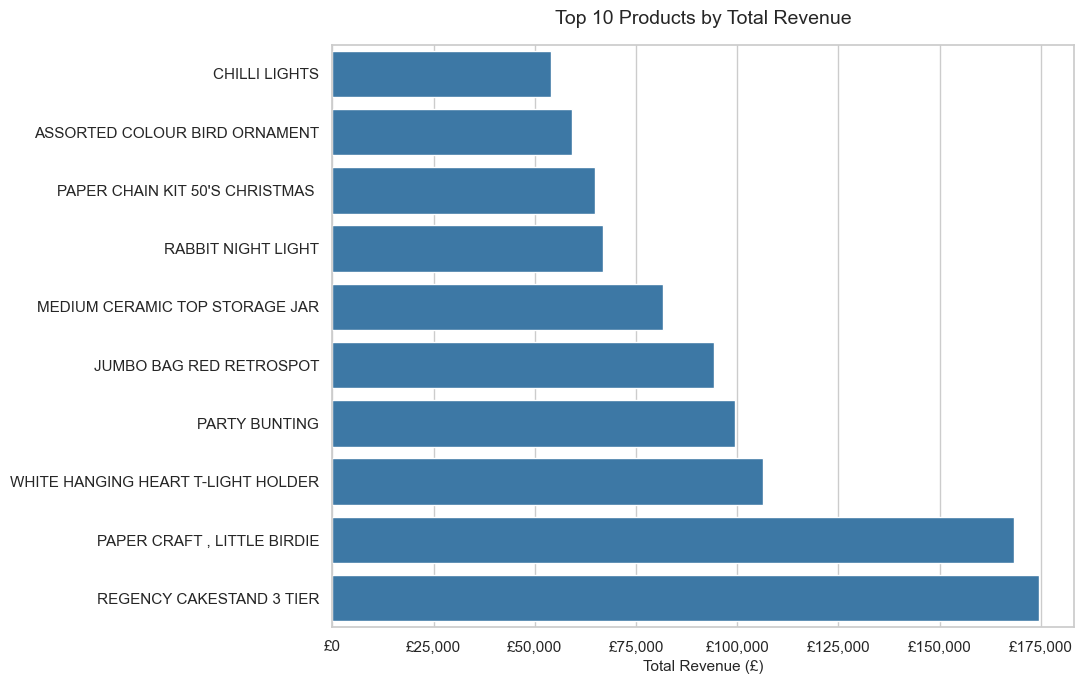

In [15]:
top_products = product_revenue.head(10).copy()
top_products = top_products.sort_values("TotalRevenue", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(data=top_products, y="Product", x="TotalRevenue", color="#2c7bb6", ax=ax)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.set_title("Top 10 Products by Total Revenue", fontsize=14, pad=15)
ax.set_xlabel("Total Revenue (£)", fontsize=11)
ax.set_ylabel("")
plt.tight_layout()

plt.savefig("../outputs/figures/top_products.png", dpi=150)
plt.show()

The top revenue-generating products are largely gift and homeware items, such as cakestands, decorative 
lights, storage jars, and seasonal ornaments. This aligns with what we'd expect from a UK wholesale 
gift retailer. The relatively tight revenue range across the top 10 suggests no single product 
dominates, which is actually a healthier product mix than the customer concentration we saw earlier.

## 8. Key Business Insights

After cleaning and analyzing 12 months of transaction data, a few clear themes emerge that 
have real implications for how this business operates.

- **This is a highly seasonal business.** Revenue nearly doubles in Q4 compared to the first 
half of the year, peaking sharply in November. For a wholesale retailer, that means inventory, 
staffing, and cash flow planning all need to be built around a Q4 surge.

- **Customer concentration is a significant risk.** The top customer alone generated over £280,000 
and the top 10 customers represent a disproportionate share of total revenue. Losing even two 
or three of these accounts would have a material impact on the bottom line.

- **The business is overwhelmingly UK-dependent.** The UK accounts for the vast majority of 
revenue, with no international market coming close. The Netherlands and Ireland show promise, 
but international revenue remains a small fraction of total sales.

- **The product mix is relatively balanced at the top.** Unlike the customer and country 
concentration, the top products are fairly evenly spread in revenue terms, meaning no single 
item dominates, and product-level risk is relatively low.

- **A large portion of transactions have no customer ID.** Over 130,000 rows lacked a CustomerID, 
limiting the depth of customer-level analysis. Improving data capture at the point of sale would 
unlock significantly better customer insights going forward.

## 9. Revenue Forecasting

With a full year of monthly revenue data in hand, we can build a simple forecast to estimate 
what the next few months might look like. In this step, we're using Prophet, a forecasting library that works well with seasonal business data like this.

In [16]:
# prophet requires a dataframe with exactly two columns: ds (date) and y (value)
prophet_df = df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"].sum().reset_index()
prophet_df.columns = ["ds", "y"]
prophet_df["ds"] = prophet_df["ds"].dt.to_timestamp()

print(prophet_df)

           ds            y
0  2010-12-01   823746.140
1  2011-01-01   691364.560
2  2011-02-01   523631.890
3  2011-03-01   717639.360
4  2011-04-01   537808.621
5  2011-05-01   770536.020
6  2011-06-01   761739.900
7  2011-07-01   719221.191
8  2011-08-01   759138.380
9  2011-09-01  1058590.172
10 2011-10-01  1154979.300
11 2011-11-01  1509496.330
12 2011-12-01   638792.680


18:22:27 - cmdstanpy - INFO - Chain [1] start processing
18:22:27 - cmdstanpy - INFO - Chain [1] done processing


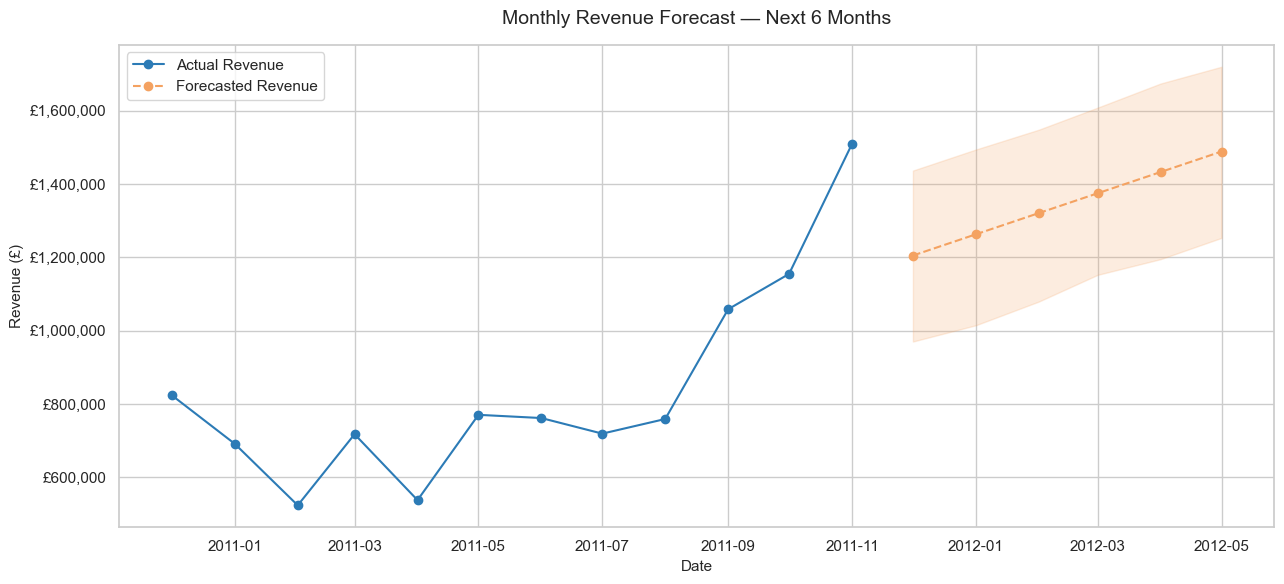

In [17]:
prophet_df_clean = prophet_df[prophet_df["ds"] < "2011-12-01"].copy()

# with only 12 months of data, yearly seasonality causes overextrapolation
# keeping it simple gives us a more honest and useful forecast
model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
model.fit(prophet_df_clean)

future = model.make_future_dataframe(periods=6, freq="MS")
forecast = model.predict(future)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(prophet_df_clean["ds"], prophet_df_clean["y"],
        marker="o", color="#2c7bb6", label="Actual Revenue")

ax.plot(forecast["ds"].tail(6), forecast["yhat"].tail(6),
        marker="o", color="#f4a261", linestyle="--", label="Forecasted Revenue")

ax.fill_between(forecast["ds"].tail(6),
                forecast["yhat_lower"].tail(6),
                forecast["yhat_upper"].tail(6),
                alpha=0.2, color="#f4a261")

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.set_title("Monthly Revenue Forecast — Next 6 Months", fontsize=14, pad=15)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Revenue (£)", fontsize=11)
ax.legend()
plt.tight_layout()

plt.savefig("../outputs/figures/revenue_forecast.png", dpi=150)
plt.show()

Using Prophet, I projected revenue for the six months following the dataset. With only 12 months 
of historical data to work with, the model keeps things conservative — forecasting a gradual 
upward trend in the £1.2M to £1.6M monthly range. The shaded area represents the uncertainty 
band, which widens as we move further into the future.

It's worth noting that a longer historical dataset would likely produce a more reliable forecast. 
What this does show, however, is that the underlying revenue trend was positive heading into 2012.